[*********************100%***********************]  1 of 1 completed


<class 'pandas.Series'>
mean: 21.106892507633653
std: 34.999160913765564


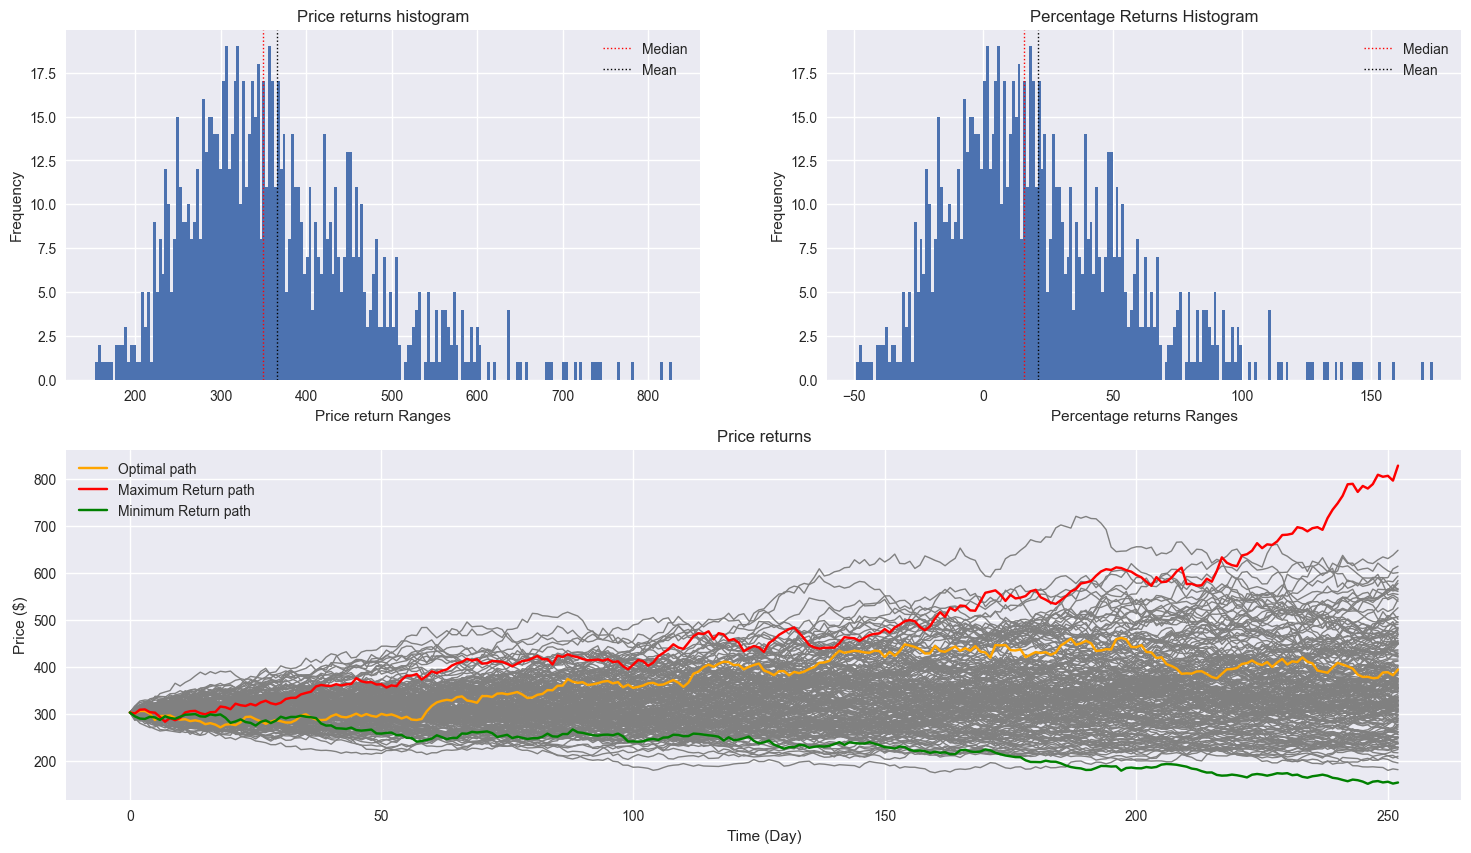

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
import pandas as pd

#Download data from yfinance
#Take Apple as our targest, simulate its future
appl = yf.download('AAPL', start = '2021-08-13', end ='2026-08-13', auto_adjust = False, multi_level_index=False)
appl_adj = appl['Adj Close']

print(type(appl_adj))
#Calc mu- mean_daily_return and sigma-mean_variance
daily_returns = appl_adj.pct_change().dropna()

daily_mu = daily_returns.mean()

daily_sigma = daily_returns.std(ddof=1)

#annualised_mu= daily_mu*252
ann_mu = daily_mu*252
ann_sigma = daily_sigma*np.sqrt(252)

S0 = appl_adj.iloc[-1]


#Piece 1: 
def simulate_gbm(S0, ann_mu, ann_sigma, days = 252, n_paths=1000, dt=1/252):
    #Piece 2: generating random shock
    e = np.random.normal(0,1,(days,n_paths))
    log_steps = (ann_mu - (ann_sigma**2)/2)*dt + ann_sigma*e*(np.sqrt(dt))
    log_paths = np.cumsum(log_steps, axis=0)
    paths = np.exp(log_paths)*S0
    paths = np.vstack([np.full(n_paths,S0),paths])
    price_returns= paths[-1,:]
    # Alternatively: paths = np.insert(paths, 0, [S0]*1000, axis = 0)
    pct_returns = (paths[-1,:]/paths[0,:]-1)*100
    print('mean:', pct_returns.mean())
    print('std:', pct_returns.std())
    return price_returns, paths, pct_returns


price_returns, paths, pct_returns = simulate_gbm(S0, ann_mu, ann_sigma, days = 252, n_paths = 1000, dt =1/252)
sorted_paths=np.sort(price_returns) #np.sort(paths)[::-1] for descending order

#optimal path
price_median = (sorted_paths[int(len(sorted_paths)/2)]+sorted_paths[int(len(sorted_paths)/2)-1])/2
price_distances = np.absolute(price_returns - price_median)
price_idx = price_distances.argmin()
op_path_return = price_returns[price_idx]
op_path = paths[:,price_idx]


#Max Return path
max_return_idx = price_returns.argmax()
max_return_path = paths[:,max_return_idx]

#Min Return path
min_return_idx = price_returns.argmin()
min_return_path = paths[:,min_return_idx]

sorted_pct = np.sort(pct_returns)
pct_median = (sorted_pct[int(len(sorted_paths)/2)]+sorted_pct[int(len(sorted_paths)/2)-1])/2
pct_mean = sorted_pct.mean()

#plotting graphs
fig = plt.figure(figsize=(18,10))
plt.style.use('seaborn-v0_8')
axes = [None]*4
axes[0]= fig.add_subplot(2,2,1)
axes[1] = fig.add_subplot(2,2,2)
axes[2] = fig.add_subplot(2,2,(3,4))


axes[0].hist(price_returns, bins = 200)
axes[0].set_title('Price returns histogram')
axes[0].set_ylabel('Frequency')
axes[0].set_xlabel('Price return Ranges')
axes[0].axvline(price_median, color='red', linestyle = ':', label='Median', linewidth = 1)
axes[0].axvline(price_returns.mean(), color='black', linestyle = ':', label='Mean', linewidth =1 )
axes[0].legend()

axes[1].hist(pct_returns, bins = 200)
axes[1].set_title('Percentage Returns Histogram')
axes[1].set_ylabel('Frequency')
axes[1].set_xlabel('Percentage returns Ranges')
axes[1].axvline(pct_median, color='red', linestyle = ':', label='Median', linewidth = 1)
axes[1].axvline(pct_mean, color='black', linestyle = ':', label='Mean', linewidth =1 )
axes[1].legend()


axes[2].plot(paths[:,np.random.choice(1000, size = 200, replace = False)], color='grey', linewidth = 1)
axes[2].plot(op_path, label = 'Optimal path', color = 'orange')
axes[2].plot(max_return_path, label = 'Maximum Return path', color = 'red')
axes[2].plot(min_return_path, label = 'Minimum Return path', color = 'green')
axes[2].set_title('Price returns')
axes[2].set_xlabel('Time (Day)')
axes[2].set_ylabel('Price ($)')
plt.legend()


plt.show()


